In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
# Sample Customer Data
data = {
    "Customer_ID": [1,2,3,4,5,6,7,8,9,10,11,12],
    "Age": [22,25,47,52,46,56,24,23,50,48,26,27],
    "Annual_Income": [15000,18000,80000,90000,85000,95000,16000,17000,88000,91000,19000,21000],
    "Spending_Score": [39,81,6,77,40,76,94,92,5,10,85,88]
}

df = pd.DataFrame(data)

print(df)

    Customer_ID  Age  Annual_Income  Spending_Score
0             1   22          15000              39
1             2   25          18000              81
2             3   47          80000               6
3             4   52          90000              77
4             5   46          85000              40
5             6   56          95000              76
6             7   24          16000              94
7             8   23          17000              92
8             9   50          88000               5
9            10   48          91000              10
10           11   26          19000              85
11           12   27          21000              88


In [3]:
X = df[['Annual_Income', 'Spending_Score']]

print(X.head())

   Annual_Income  Spending_Score
0          15000              39
1          18000              81
2          80000               6
3          90000              77
4          85000              40


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Data Standardized Successfully!")

Data Standardized Successfully!


In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print(df)

    Customer_ID  Age  Annual_Income  Spending_Score  Cluster
0             1   22          15000              39        2
1             2   25          18000              81        1
2             3   47          80000               6        0
3             4   52          90000              77        0
4             5   46          85000              40        0
5             6   56          95000              76        0
6             7   24          16000              94        1
7             8   23          17000              92        1
8             9   50          88000               5        0
9            10   48          91000              10        0
10           11   26          19000              85        1
11           12   27          21000              88        1


In [6]:

centers = scaler.inverse_transform(kmeans.cluster_centers_)

print("Cluster Centers:")
print(centers)

Cluster Centers:
[[8.81666667e+04 3.56666667e+01]
 [1.82000000e+04 8.80000000e+01]
 [1.50000000e+04 3.90000000e+01]]


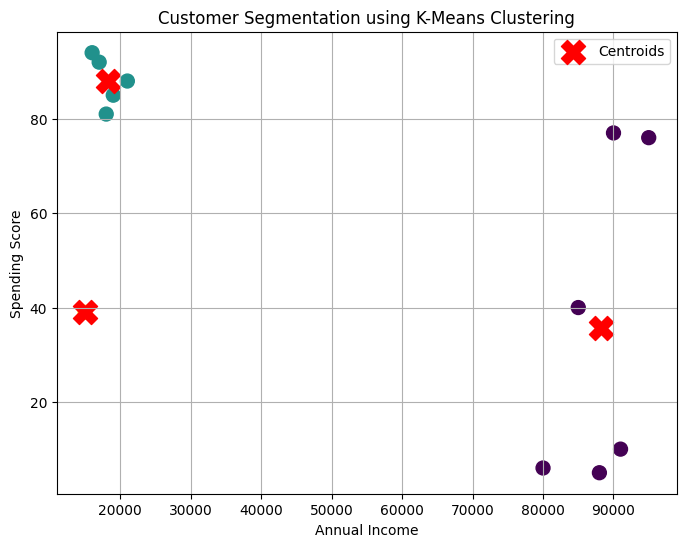

In [7]:
plt.figure(figsize=(8,6))

plt.scatter(df["Annual_Income"],
            df["Spending_Score"],
            c=df["Cluster"],
            cmap="viridis",
            s=100)

plt.scatter(centers[:,0],
            centers[:,1],
            color='red',
            marker='X',
            s=300,
            label="Centroids")

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation using K-Means Clustering")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
for cluster in sorted(df["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    print(df[df["Cluster"] == cluster])


Cluster 0
   Customer_ID  Age  Annual_Income  Spending_Score  Cluster
2            3   47          80000               6        0
3            4   52          90000              77        0
4            5   46          85000              40        0
5            6   56          95000              76        0
8            9   50          88000               5        0
9           10   48          91000              10        0

Cluster 1
    Customer_ID  Age  Annual_Income  Spending_Score  Cluster
1             2   25          18000              81        1
6             7   24          16000              94        1
7             8   23          17000              92        1
10           11   26          19000              85        1
11           12   27          21000              88        1

Cluster 2
   Customer_ID  Age  Annual_Income  Spending_Score  Cluster
0            1   22          15000              39        2
